In [2]:
# Ячейка 1: Импорты и настройка
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['figure.dpi'] = 100

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {device}")

Устройство: cpu


In [39]:
class NeuralPhotoPE(nn.Module):
    """
    Улучшенная версия с positional encoding для чётких границ.
    """
    def __init__(self, hidden_dim=512, num_layers=6, num_frequencies=10):
        super().__init__()
        
        # Positional encoding: преобразует x,y в sin/cos сигналы
        self.num_frequencies = num_frequencies
        input_dim = 2 + 4 * num_frequencies  # 2 исходные + sin/cos компоненты
        
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.SiLU())
        
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())
        
        layers.append(nn.Linear(hidden_dim, 3))
        layers.append(nn.Sigmoid())
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, coords):
        # Positional encoding (тот же принцип, что в Transformers и NeRF!)
        x = coords  # (N, 2)
        
        encoded = [x]
        for i in range(self.num_frequencies):
            freq = 2.0 ** i
            encoded.append(torch.sin(freq * x))
            encoded.append(torch.cos(freq * x))
        
        x_encoded = torch.cat(encoded, dim=-1)
        return self.net(x_encoded)


def count_params(model):
    return sum(p.numel() for p in model.parameters())

In [48]:
# Ячейка 3: Параметры нейросети (меняй здесь!)
MAX_SIZE = 256

HIDDEN_DIM = 128        # БЫЛО 64 → Больше нейронов для сложных паттернов
NUM_LAYERS = 4          # БЫЛО 3 → Глубже
NUM_FREQUENCIES = 8     # БЫЛО 4 → Критично! Отвечает за чёткость границ
EPOCHS = 3000           # БЫЛО 1000 → Больше итераций
LEARNING_RATE = 3e-4    # БЫЛО 1e-3 → Меньше lr для стабильности


model = NeuralPhotoPE(
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_frequencies=NUM_FREQUENCIES
).to(device)


print(f"Параметров: {count_params(model):,} ({count_params(model)*4/1024:.1f} КБ)")
print(f"Сжатие: {H*W*3/1024:.0f} КБ → {count_params(model)*4/1024:.1f} КБ")
print(f"Коэффициент: в {H*W*3/(count_params(model)*4):.0f} раз")


Параметров: 54,403 (212.5 КБ)
Сжатие: 124 КБ → 212.5 КБ
Коэффициент: в 1 раз


Фото загружено: 256×165 = 42,240 пикселей
Координаты: torch.Size([42240, 2])
Цвета: torch.Size([42240, 3])


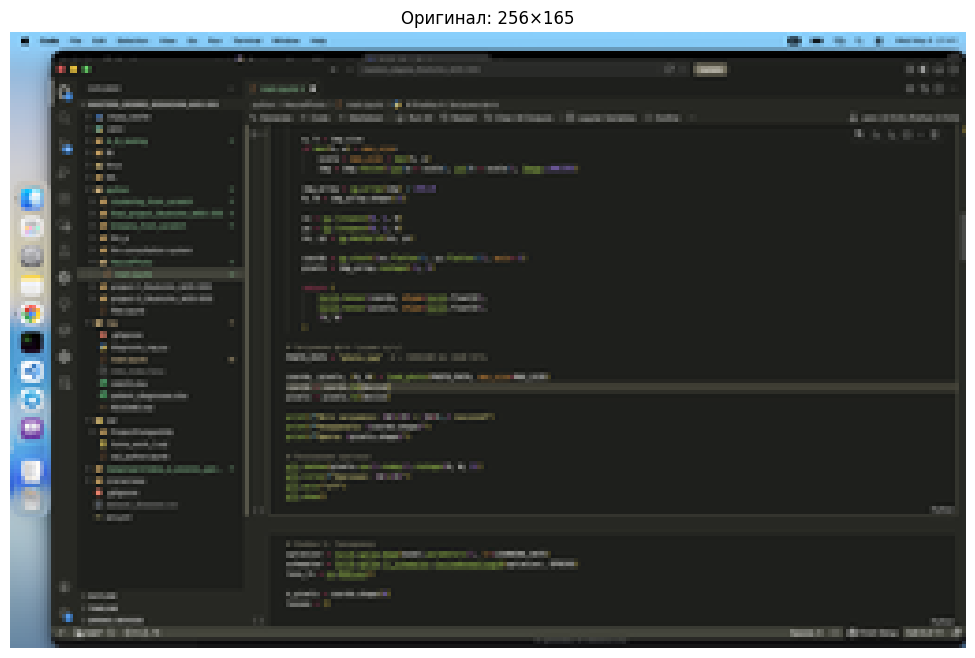

In [49]:
# Ячейка 4: Загрузка фото
def load_photo(image_path, max_size=512):
    """Загружает фото и преобразует в тренировочные данные"""
    img = Image.open(image_path).convert("RGB")
    
    w, h = img.size
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    
    img_array = np.array(img) / 255.0
    H, W = img_array.shape[:2]
    
    xs = np.linspace(0, 1, W)
    ys = np.linspace(0, 1, H)
    xx, yy = np.meshgrid(xs, ys)
    
    coords = np.stack([xx.flatten(), yy.flatten()], axis=-1)
    pixels = img_array.reshape(-1, 3)
    
    return (
        torch.tensor(coords, dtype=torch.float32),
        torch.tensor(pixels, dtype=torch.float32),
        (H, W)
    )

# Загружаем фото (укажи путь)
PHOTO_PATH = "/Users/phil/GitHub/masters_degree_Roshchin_M25-555/python/NeuralPhoto/1.png"  # ← ПОМЕНЯЙ НА СВОЙ ПУТЬ

coords, pixels, (H, W) = load_photo(PHOTO_PATH, max_size=MAX_SIZE)
coords = coords.to(device)
pixels = pixels.to(device)

print(f"Фото загружено: {W}×{H} = {W*H:,} пикселей")
print(f"Координаты: {coords.shape}")
print(f"Цвета: {pixels.shape}")

# Показываем оригинал
plt.imshow(pixels.cpu().numpy().reshape(H, W, 3))
plt.title(f"Оригинал: {W}×{H}")
plt.axis("off")
plt.show()

Запоминаю фото:   0%|          | 0/3000 [00:00<?, ?it/s]


Финальный loss: 0.003553


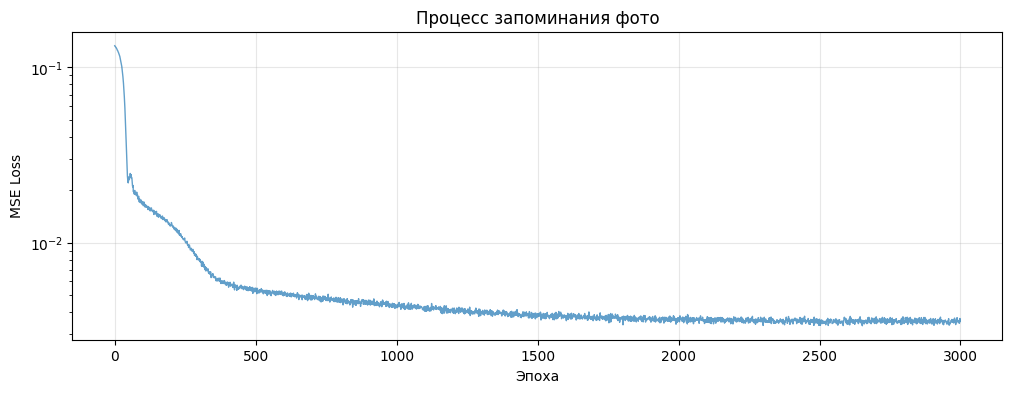

In [50]:
# Ячейка 5: Тренировка
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS)
loss_fn = nn.MSELoss()

n_pixels = coords.shape[0]
losses = []

pbar = tqdm(range(EPOCHS), desc="Запоминаю фото")
for epoch in pbar:
    # Случайный батч
    indices = torch.randperm(n_pixels, device=device)[:BATCH_SIZE]
    batch_coords = coords[indices]
    batch_pixels = pixels[indices]
    
    # Forward
    predicted = model(batch_coords)
    loss = loss_fn(predicted, batch_pixels)
    
    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    losses.append(loss.item())
    pbar.set_postfix(loss=f"{loss.item():.6f}")

print(f"\nФинальный loss: {losses[-1]:.6f}")

# График обучения
plt.figure(figsize=(12, 4))
plt.plot(losses, alpha=0.7, linewidth=1)
plt.xlabel("Эпоха")
plt.ylabel("MSE Loss")
plt.title("Процесс запоминания фото")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.show()

Восстанавливаю фото из нейросети...


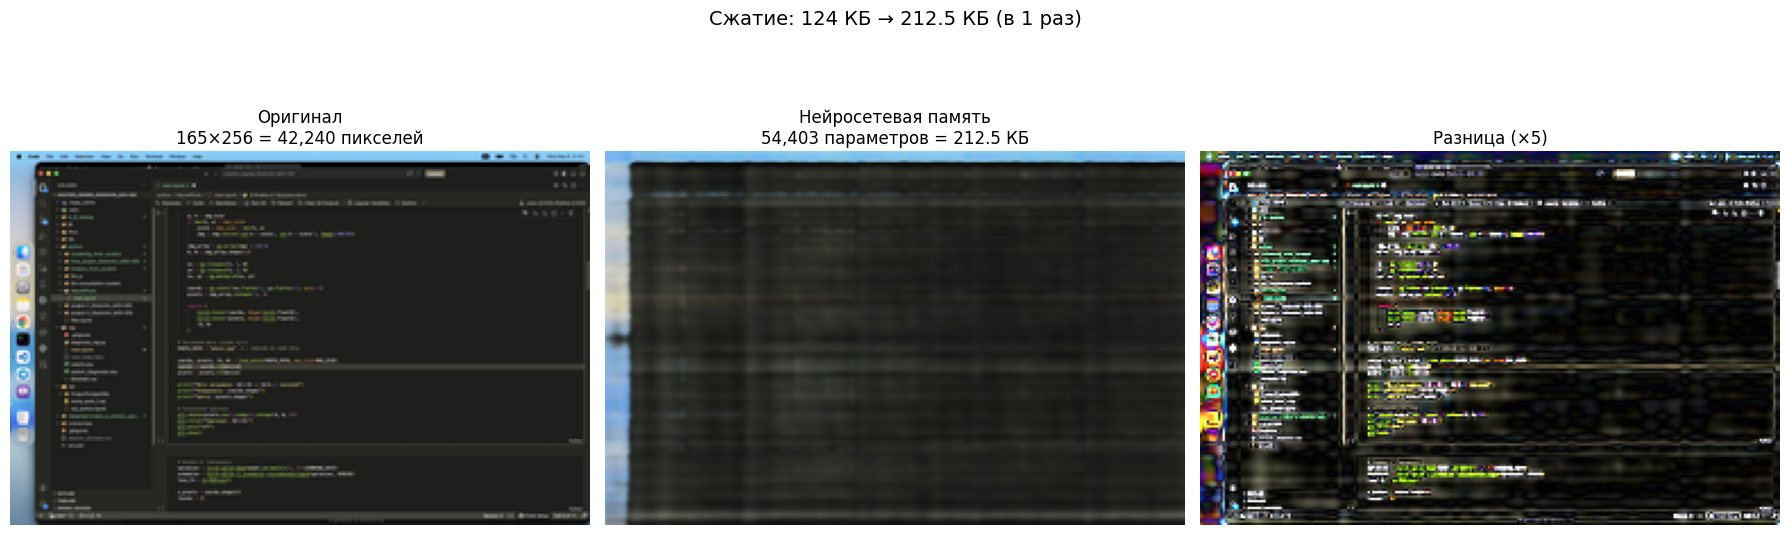

PSNR: 24.50 dB (выше = лучше, >30 отлично, >40 идеально)
MSE: 0.003550


In [51]:
# Ячейка 6: Восстановление фото
def render_photo(model, H, W):
    """Восстанавливает фото из нейросети"""
    model.eval()
    
    xs = torch.linspace(0, 1, W)
    ys = torch.linspace(0, 1, H)
    xx, yy = torch.meshgrid(xs, ys, indexing="xy")
    coords = torch.stack([xx.flatten(), yy.flatten()], dim=-1).to(device)
    
    batch_size = 16384
    colors = []
    
    with torch.no_grad():
        for i in range(0, coords.shape[0], batch_size):
            batch = coords[i:i + batch_size]
            colors.append(model(batch).cpu().numpy())
    
    return np.concatenate(colors, axis=0).reshape(H, W, 3)

print("Восстанавливаю фото из нейросети...")
reconstructed = render_photo(model, H, W)

# Сравнение
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

original = pixels.cpu().numpy().reshape(H, W, 3)

axes[0].imshow(original)
axes[0].set_title(f"Оригинал\n{H}×{W} = {H*W:,} пикселей", fontsize=12)
axes[0].axis("off")

axes[1].imshow(np.clip(reconstructed, 0, 1))
axes[1].set_title(f"Нейросетевая память\n{count_params(model):,} параметров = {count_params(model)*4/1024:.1f} КБ", fontsize=12)
axes[1].axis("off")

diff = np.abs(original - reconstructed) * 5
axes[2].imshow(np.clip(diff, 0, 1))
axes[2].set_title("Разница (×5)", fontsize=12)
axes[2].axis("off")

plt.suptitle(
    f"Сжатие: {H*W*3/1024:.0f} КБ → {count_params(model)*4/1024:.1f} КБ "
    f"(в {H*W*3/(count_params(model)*4):.0f} раз)",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

# Метрики качества
psnr = -10 * np.log10(np.mean((original - reconstructed) ** 2))
print(f"PSNR: {psnr:.2f} dB (выше = лучше, >30 отлично, >40 идеально)")
print(f"MSE: {np.mean((original - reconstructed) ** 2):.6f}")

In [52]:
# Ячейка-анализатор качества
import numpy as np

# Считаем статистику по ошибкам
diff = np.abs(original - reconstructed)
print("Статистика ошибки (без усиления):")
print(f"  Средняя ошибка: {diff.mean():.4f} ({diff.mean()*100:.2f}%")
print(f"  Максимальная ошибка: {diff.max():.4f} ({diff.max()*100:.2f}%)")
print(f"  Медианная ошибка: {np.median(diff):.4f}")

# Сколько пикселей "хорошие" (ошибка < 5%)
good_pixels = (diff < 0.05).all(axis=-1).sum()
total_pixels = H * W
print(f"\n  Хороших пикселей: {good_pixels}/{total_pixels} ({good_pixels/total_pixels*100:.1f}%)")

# PSNR
mse = np.mean((original - reconstructed) ** 2)
psnr = -10 * np.log10(mse)
print(f"\n  PSNR: {psnr:.1f} dB")

if psnr > 40:
    print("  🟢 Отлично! Визуально неотличимо от оригинала")
elif psnr > 35:
    print("  🟡 Хорошо. Разница заметна только при приближении")
elif psnr > 30:
    print("  🟠 Средне. Размытость видна невооружённым глазом")
else:
    print("  🔴 Плохо. Сильная размытость")

Статистика ошибки (без усиления):
  Средняя ошибка: 0.0339 (3.39%
  Максимальная ошибка: 0.9246 (92.46%)
  Медианная ошибка: 0.0177

  Хороших пикселей: 31926/42240 (75.6%)

  PSNR: 24.5 dB
  🔴 Плохо. Сильная размытость


In [53]:
print(f"Память модели: {count_params(model) * 4 / 1024:.1f} КБ")

Память модели: 212.5 КБ
